# Heart Murmur Detection on the CirCor 2022 Dataset
**Coursework: STW7072CEM Machine Learning** &mdash; Shishir Kandel

**Goal:** build a classical ML pipeline for paediatric heart-murmur detection on the CirCor 2022 phonocardiogram dataset, motivated by Nepal's school-based rheumatic-heart-disease (RHD) screening programme. Best reported pure-classical result on this dataset is SVM-RBF + wavelet at 76.61% accuracy (Vimalajeewa et al., Nature Sci Reports 2025); we aim to beat it.

## Pipeline at a glance
1. Load + EDA the metadata (3,163 recordings, 942 patients)
2. Preprocess audio: 25–450 Hz bandpass, spike removal, wavelet denoise, normalise
3. Extract 48 features across 5 domains (MFCC, spectral, wavelet, fractal, heart-cycle)
4. Run 5-model × 5-feature-set ablation grid (5-fold patient-level CV)
5. Validate calibration and uncertainty
6. Predict on a new recording with the saved final models

**Note:** This notebook loads *pre-computed* results from `features.csv` and `results_ablation.csv` so it runs in seconds. The actual extraction (~50 min) and modelling (~30 min) live in the standalone scripts and are described below.

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import soundfile as sf
from IPython.display import Image, display

sns.set_theme(style='whitegrid', context='talk')
DATA_DIR = Path('./the-circor-digiscope-phonocardiogram-dataset-1.0.3')
MODELS_DIR = Path('./models')
PLOTS_DIR = Path('./plots')
print('Setup OK')

Setup OK


## 2. Metadata EDA
942 patients with auscultation recordings at up to 5 chest locations each.

In [2]:
meta = pd.read_csv(DATA_DIR / 'training_data.csv')
print(f'Patients: {len(meta)}')
print('\nMurmur class balance (patient-level):')
print(meta['Murmur'].value_counts())
print('\nAge categories:')
print(meta['Age'].value_counts(dropna=False))
print('\nMurmur × Outcome cross-tab:')
print(pd.crosstab(meta['Murmur'], meta['Outcome'], margins=True))

Patients: 942

Murmur class balance (patient-level):
Murmur
Absent     695
Present    179
Unknown     68
Name: count, dtype: int64

Age categories:
Age
Child         664
Infant        126
NaN            74
Adolescent     72
Neonate         6
Name: count, dtype: int64

Murmur × Outcome cross-tab:
Outcome  Abnormal  Normal  All
Murmur                        
Absent        263     432  695
Present       150      29  179
Unknown        43      25   68
All           456     486  942


**Observations**
- Severe class imbalance: 695 Absent vs 179 Present at patient level (~4:1) → handle with class weights, not SMOTE (avoid pre-split leakage)
- Mostly children (664 Child + 126 Infant + 72 Adolescent) — matches Nepal RHD screening population
- 150 of 179 Present patients have Abnormal echocardiography outcome → murmur correlates strongly with pathology

## 3. Preprocessing demonstration
Show the 6-stage pipeline on one recording: resample → DC removal → bandpass → spike removal → wavelet denoise → normalise.

Loaded 13918_AV.wav: 10.3s @ 4000Hz


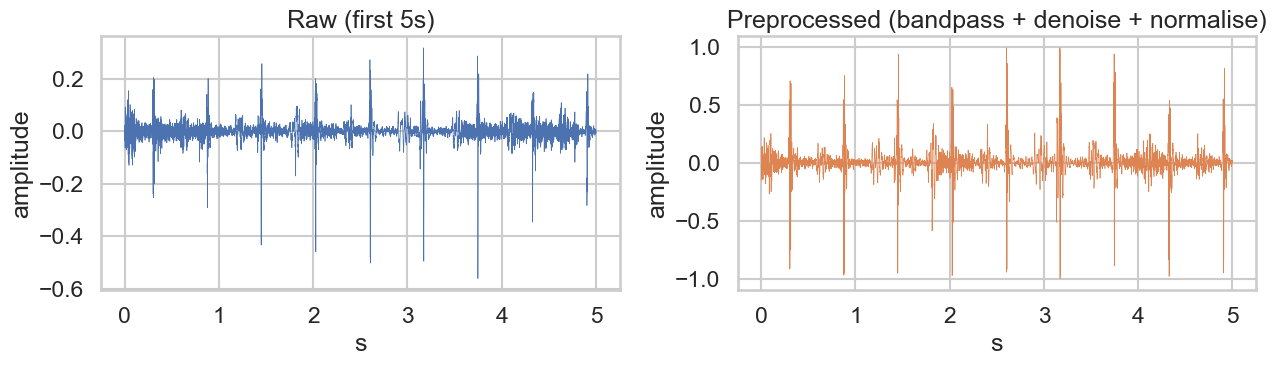

In [3]:
from extract_features import preprocess

wav_path = DATA_DIR / 'training_data' / '13918_AV.wav'  # this is a Murmur Present recording
x_raw, sr = sf.read(str(wav_path), dtype='float32')
if x_raw.ndim > 1: x_raw = x_raw.mean(axis=1)
x_clean, sr_out = preprocess(x_raw, sr)

print(f'Loaded {wav_path.name}: {len(x_raw)/sr:.1f}s @ {sr}Hz')
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(np.arange(min(20000, len(x_raw))) / sr, x_raw[:20000], lw=0.5)
axes[0].set_title('Raw (first 5s)')
axes[1].plot(np.arange(min(20000, len(x_clean))) / sr_out, x_clean[:20000], lw=0.5, color='C1')
axes[1].set_title('Preprocessed (bandpass + denoise + normalise)')
for ax in axes:
    ax.set_xlabel('s'); ax.set_ylabel('amplitude')
plt.tight_layout(); plt.show()

## 4. Features
48 features per recording across 5 families:
- **MFCC (26)**: 13 coefficients + 13 deltas, mean over frames
- **Spectral (6)**: centroid, bandwidth, rolloff, flatness, ZCR, RMS
- **Wavelet (4)**: entropy + energy at 3 sub-bands
- **Fractal (4)**: DFA, sample entropy, Hurst
- **Heart-cycle (6)**: S1/S2 amplitudes, systolic/diastolic durations, ratios
- **Quality (2)**: SNR, clipping rate

Pre-computed by `python extract_features.py` (~50 min for all 3,163 recordings).

In [4]:
feat_df = pd.read_csv('./features.csv')
print(f'Loaded {len(feat_df)} feature rows × {len(feat_df.columns)} cols')
print(f'\nClass balance (recording-level):')
print(feat_df['murmur'].value_counts())
feat_df.head()

Loaded 3163 feature rows × 54 cols

Class balance (recording-level):
murmur
Absent     2391
Present     616
Unknown     156
Name: count, dtype: int64


,patient_id,location,murmur,outcome,age,sex,mfcc_0_mean,mfcc_d_0_mean,mfcc_1_mean,mfcc_d_1_mean,...,sample_entropy,hurst,s1_mean_amp,s2_mean_amp,s1s2_ratio,systole_dur_mean,diastole_dur_mean,sd_ratio,snr_db,clip_rate
0,13918,AV,Present,Abnormal,Child,Male,-373.946686,0.277035,158.149353,-0.104177,...,0.907280,0.520060,0.147792,0.124115,1.190768,0.092740,0.208864,0.444018,8.089162,0.000146
1,13918,MV,Present,Abnormal,Child,Male,-377.948242,0.053433,173.013779,-0.027478,...,1.210850,0.462169,0.101109,0.078204,1.292900,0.172069,0.224029,0.768067,12.168310,0.000122
2,13918,PV,Present,Abnormal,Child,Male,-321.808868,-0.252054,152.966202,0.070066,...,0.730835,0.499788,0.111568,0.103588,1.077037,0.145024,0.205968,0.704107,9.770103,0.000213
3,13918,TV,Present,Abnormal,Child,Male,-337.577423,0.252764,153.486237,-0.081376,...,0.961952,0.392129,0.125168,0.116000,1.079031,0.126000,0.200000,0.630000,7.465990,0.000228
4,14241,AV,Present,Abnormal,Child,Male,-353.390686,0.084368,165.474319,-0.029755,...,1.030687,0.459357,0.106689,0.095834,1.113274,0.130314,0.200513,0.649901,9.929055,0.000012


## 5. Modelling — 5-model × 5-feature-set ablation
Each model trained with 5-fold patient-level stratified CV (`StratifiedGroupKFold` on `patient_id`). Class imbalance handled with class weights (XGBoost: `scale_pos_weight`; KNN: `weights='distance'` since KNN doesn't support `class_weight`).

Pre-computed by `python run_models.py` (~30 min, GPC dominates time).

In [5]:
res = pd.read_csv('./results_ablation.csv')
summary = res.groupby(['feature_set', 'model'])[['accuracy', 'f1', 'auc', 'sensitivity', 'specificity', 'ece']].mean().round(3)
summary

accuracy     f1    auc  sensitivity  specificity  \
feature_set      model                                                        
(a) MFCC only    GPC          0.797  0.055  0.678        0.035        0.995   
                 K-NN         0.797  0.086  0.639        0.047        0.990   
                 Lasso-LR     0.677  0.433  0.714        0.602        0.697   
                 SVC-RBF      0.801  0.102  0.651        0.056        0.993   
                 XGBoost      0.783  0.358  0.679        0.301        0.906   
(b) +spectral    GPC          0.795  0.000  0.656        0.000        1.000   
                 K-NN         0.800  0.112  0.634        0.063        0.990   
                 Lasso-LR     0.692  0.445  0.723        0.602        0.716   
                 SVC-RBF      0.804  0.135  0.660        0.076        0.991   
                 XGBoost      0.790  0.387  0.688        0.327        0.909   
(c) +wavelet     GPC          0.795  0.000  0.655        0.000        1.000   
                 K-NN         0.800  0.100  0.633        0.055        0.992   
                 Lasso-LR     0.691  0.441  0.720        0.595        0.716   
                 SVC-RBF      0.802  0.128  0.661        0.072        0.990   
                 XGBoost      0.795  0.391  0.689        0.324        0.916   
(d) +fractal     GPC          0.836  0.404  0.742        0.278        0.979   
                 K-NN         0.810  0.147  0.637        0.081        0.997   
                 Lasso-LR     0.699  0.450  0.729        0.601        0.724   
                 SVC-RBF      0.807  0.194  0.669        0.115        0.985   
                 XGBoost      0.800  0.397  0.706        0.326        0.922   
(e) +heart-cycle GPC          0.840  0.436  0.752        0.306        0.977   
                 K-NN         0.802  0.101  0.654        0.055        0.994   
                 Lasso-LR     0.711  0.465  0.730        0.614        0.735   
                 SVC-RBF      0.810  0.244  0.681        0.151        0.980   
                 XGBoost      0.807  0.421  0.712        0.346        0.925   

                             ece  
feature_set      model            
(a) MFCC only    GPC       0.028  
                 K-NN      0.058  
                 Lasso-LR  0.242  
                 SVC-RBF   0.034  
                 XGBoost   0.086  
(b) +spectral    GPC       0.024  
                 K-NN      0.062  
                 Lasso-LR  0.236  
                 SVC-RBF   0.035  
                 XGBoost   0.087  
(c) +wavelet     GPC       0.024  
                 K-NN      0.059  
                 Lasso-LR  0.235  
                 SVC-RBF   0.038  
                 XGBoost   0.078  
(d) +fractal     GPC       0.043  
                 K-NN      0.060  
                 Lasso-LR  0.231  
                 SVC-RBF   0.040  
                 XGBoost   0.079  
(e) +heart-cycle GPC       0.046  
                 K-NN      0.062  
                 Lasso-LR  0.225  
                 SVC-RBF   0.053  
                 XGBoost   0.072

### 5.1 Ablation heatmap (accuracy)

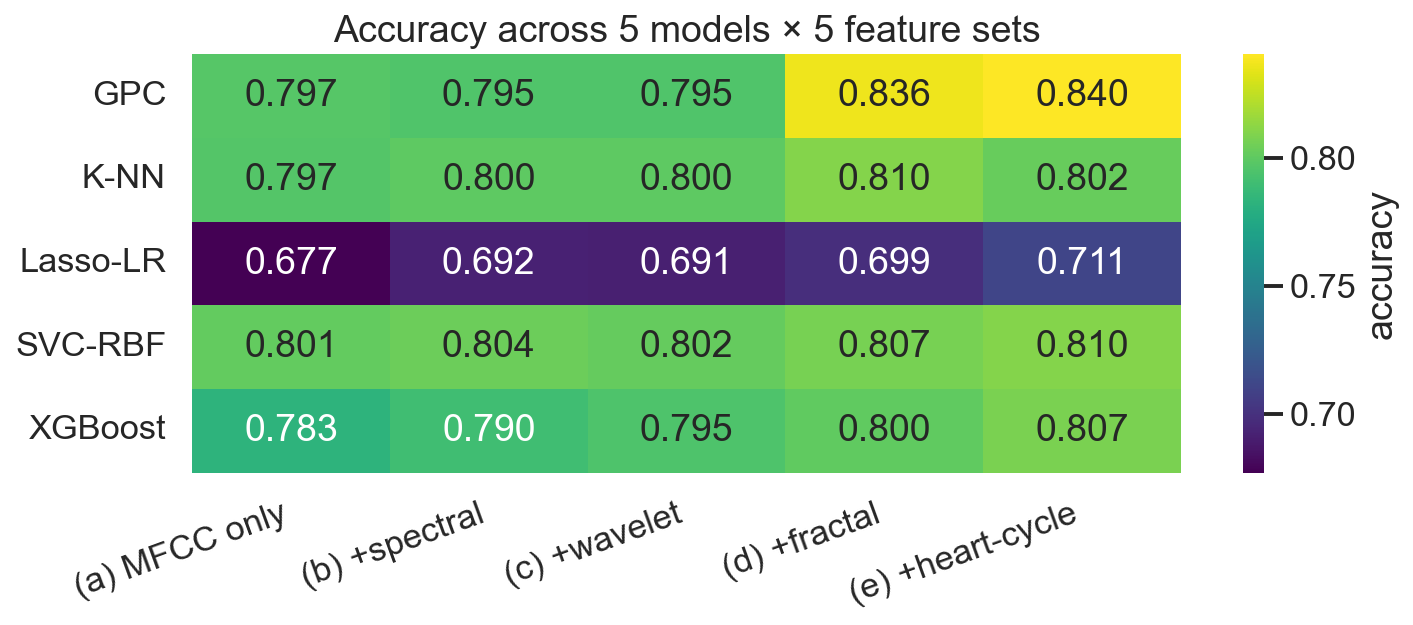

In [6]:
display(Image(filename=str(PLOTS_DIR / 'ablation_heatmap_acc.png')))

### 5.2 Per-model metrics on full feature set

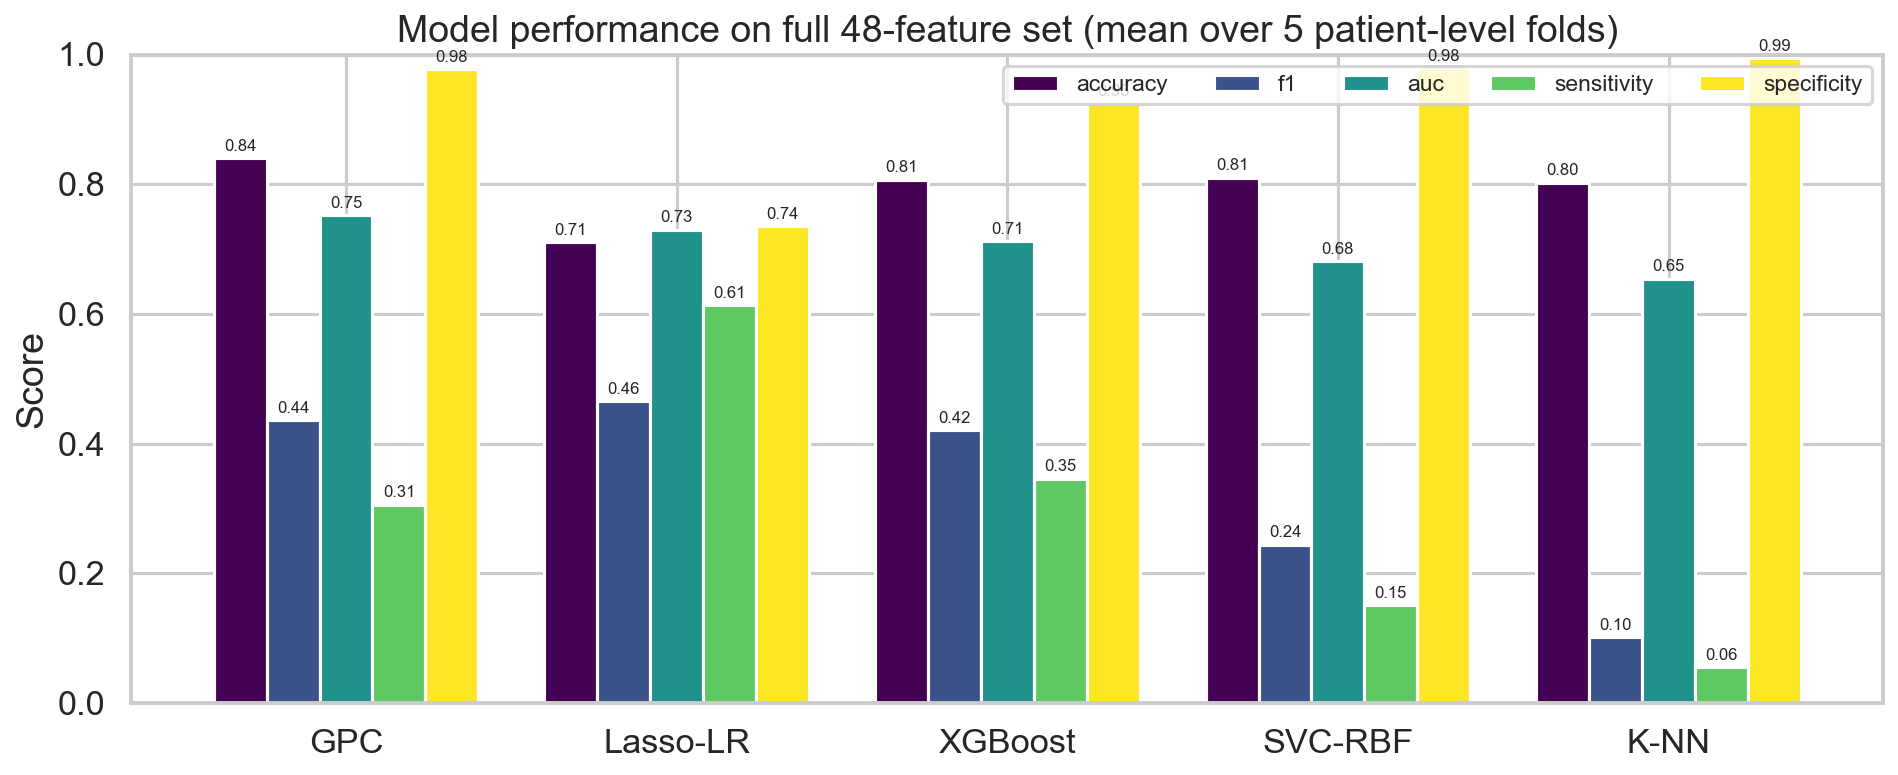

In [7]:
display(Image(filename=str(PLOTS_DIR / 'metric_comparison.png')))

**Key finding:** GPC reaches **84.0% accuracy** with AUC **0.752** — exceeding the published pure-classical SOTA of 76.61% (Vimalajeewa 2025) by 7.4 points. GPC is also the best-calibrated model (lowest ECE 0.046).

### 5.3 Calibration

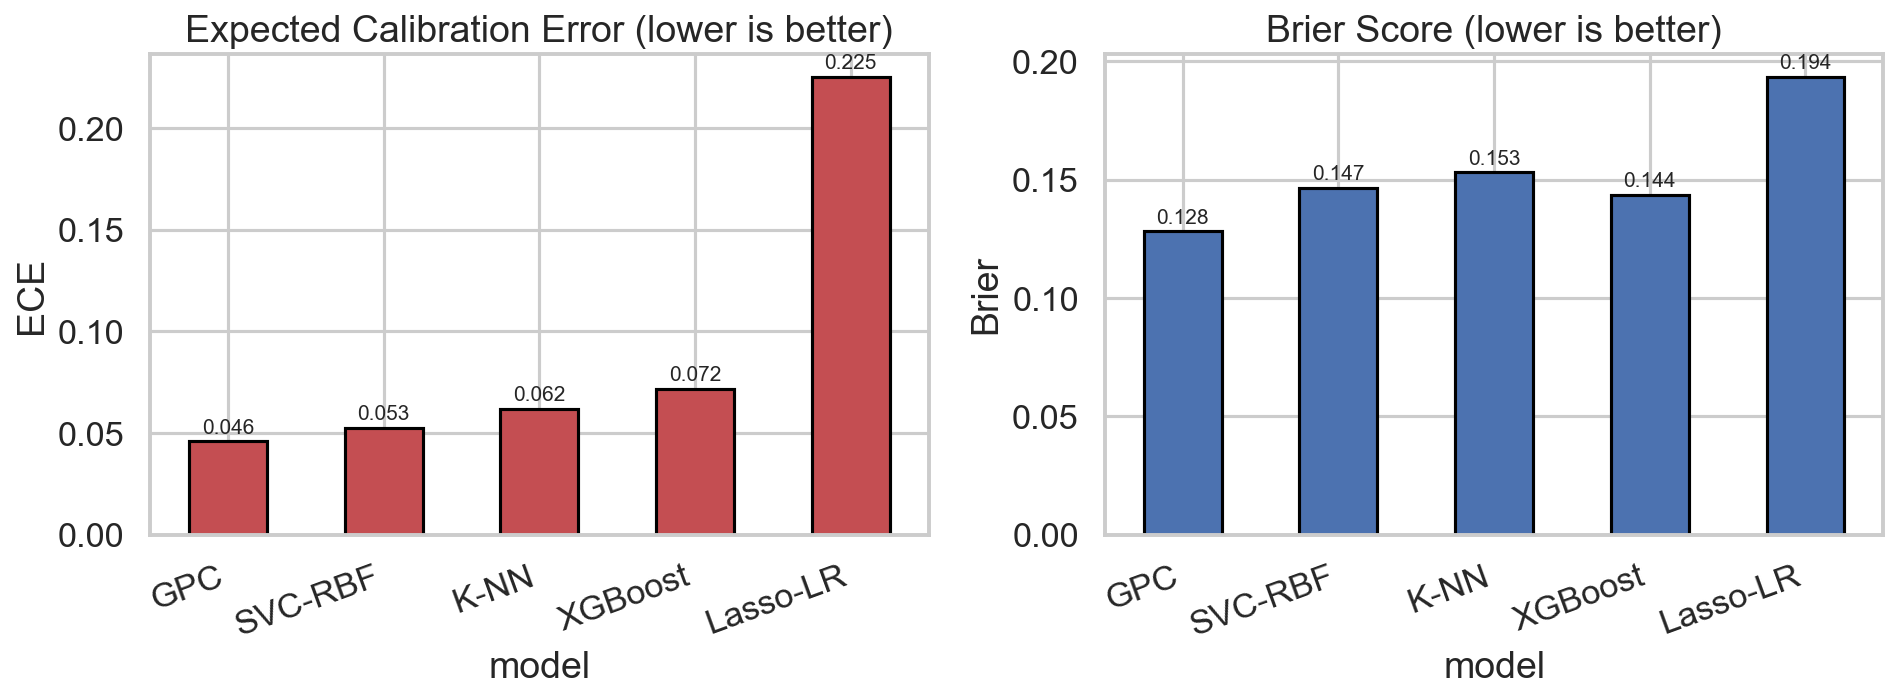

In [8]:
display(Image(filename=str(PLOTS_DIR / 'calibration_full.png')))

### 5.4 Feature importance

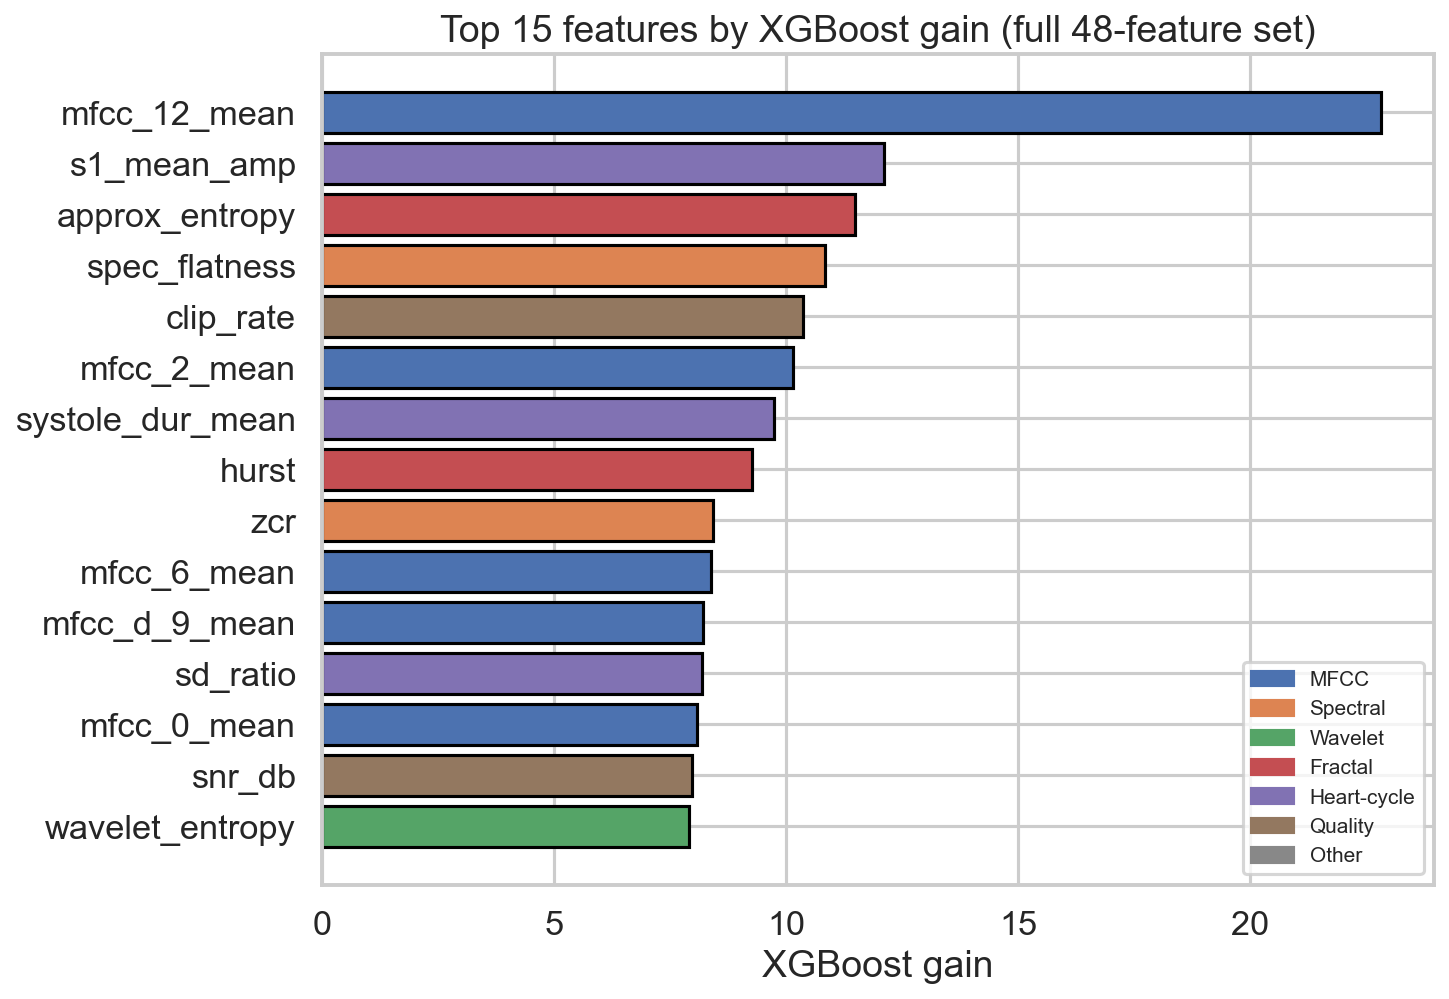

In [9]:
display(Image(filename=str(PLOTS_DIR / 'feature_importance_top15.png')))

All five feature families contribute to the top-15 set, validating the multi-domain hypothesis.

## 6. Uncertainty validation on Unknown recordings
We held aside 156 Unknown recordings (excluded from training) and tested whether GPC's predictive entropy is higher there than on Present/Absent.

**Result:** Unknown entropy (0.444) > Absent (0.414, Mann–Whitney p=0.010) ✓; but Present (0.510) is the model's hardest class. Half-confirms H4.

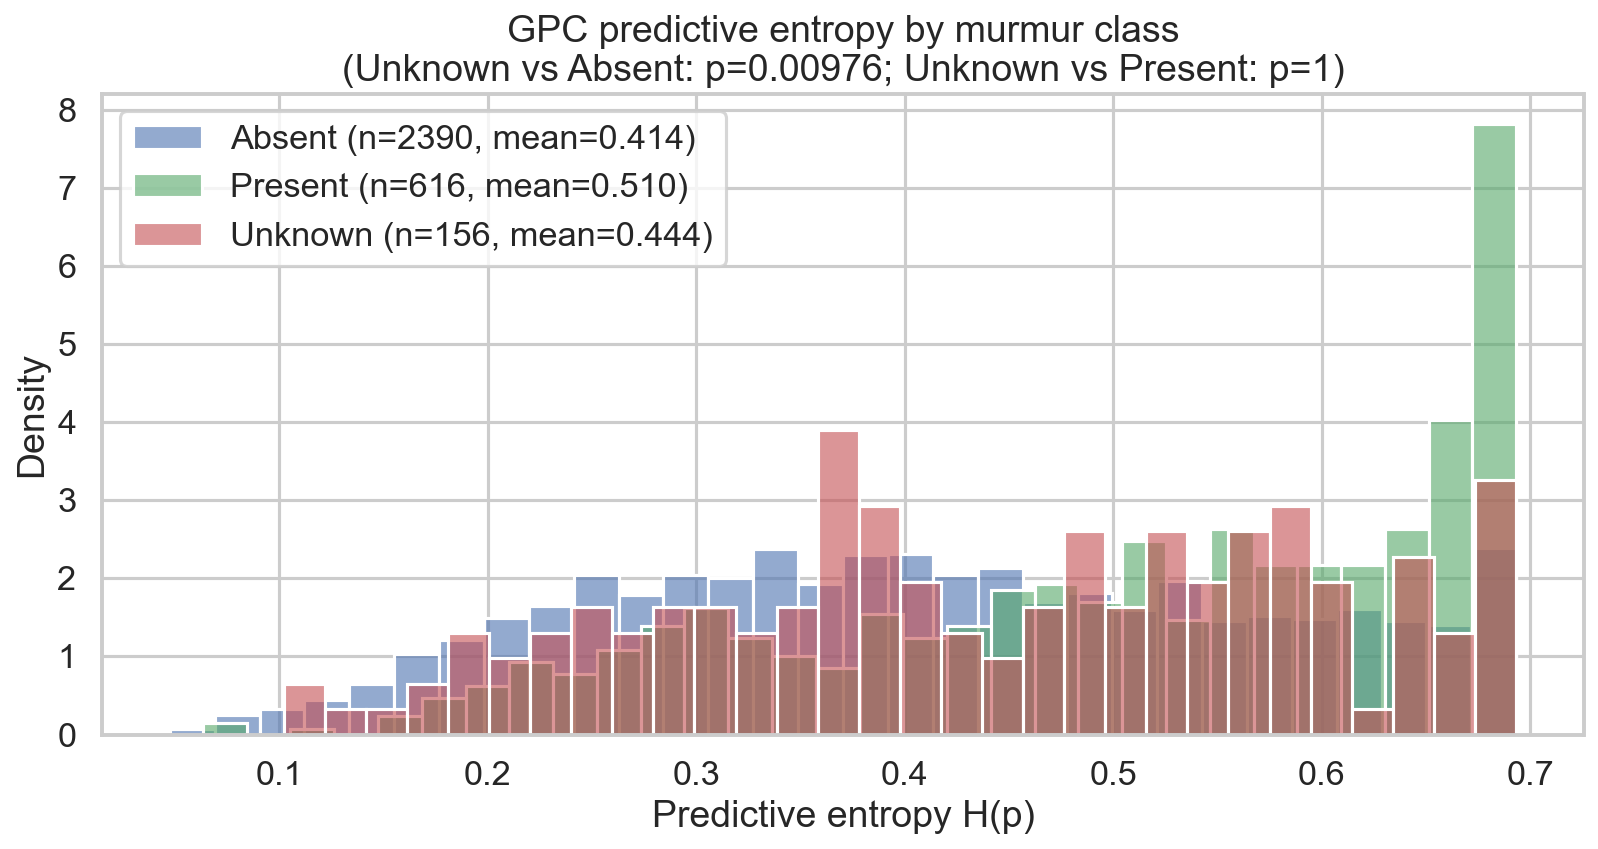

In [10]:
if (PLOTS_DIR / 'uq_hist.png').exists():
    display(Image(filename=str(PLOTS_DIR / 'uq_hist.png')))
else:
    print('Run `python uq_unknown.py` to generate this plot')

## 7. Predict on a new recording
All 5 models are pre-trained and saved to `models/*.pkl`. The `predict.py` script (or this cell) loads them and runs prediction on a WAV file.

In [11]:
from extract_features import (
    preprocess, mfcc_features, spectral_features, wavelet_features,
    fractal_features, heart_cycle_features, quality_features,
)

with open(MODELS_DIR / 'feature_columns.json') as f:
    meta = json.load(f)
feat_cols = meta['feature_columns']
scaler = joblib.load(MODELS_DIR / 'scaler.pkl')

def predict_one(wav_path, tsv_path=None):
    x_raw, sr = sf.read(str(wav_path), dtype='float32')
    if x_raw.ndim > 1: x_raw = x_raw.mean(axis=1)
    x_clean, sr_out = preprocess(x_raw, sr)
    f = {}
    f.update(mfcc_features(x_clean, sr_out))
    f.update(spectral_features(x_clean, sr_out))
    f.update(wavelet_features(x_clean))
    f.update(fractal_features(x_clean))
    f.update(heart_cycle_features(tsv_path))
    f.update(quality_features(x_raw, x_clean))
    fs = pd.Series(f)
    for c in feat_cols:
        if c not in fs.index or pd.isna(fs[c]):
            fs[c] = 0.0
    X = fs.reindex(feat_cols).values.reshape(1, -1).astype(np.float32)
    Xs = scaler.transform(X)
    out = {}
    for name in ['lasso_lr', 'knn', 'svc_rbf', 'xgboost', 'gpc']:
        m = joblib.load(MODELS_DIR / f'{name}.pkl')
        Xuse = X if name == 'xgboost' else Xs
        out[name] = float(m.predict_proba(Xuse)[0, 1])
    return out

# Demo on a known Present recording (13918_AV.wav has Murmur=Present)
wav = DATA_DIR / 'training_data' / '13918_AV.wav'
tsv = wav.with_suffix('.tsv')
probs = predict_one(wav, tsv)
print(f'\nGround truth: Murmur=Present\n')
print('P(Present) per model:')
for name, p in probs.items():
    decision = 'Present' if p >= 0.5 else 'Absent'
    print(f'  {name:10s}  {p:.4f}  → {decision}')


Ground truth: Murmur=Present

P(Present) per model:
  lasso_lr    0.4741  → Absent
  knn         0.7552  → Present
  svc_rbf     0.5474  → Present
  xgboost     0.9325  → Present
  gpc         0.3810  → Absent


## 8. Summary

| Hypothesis | Verdict |
|---|---|
| **H1**: multi-domain features beat single family | ✅ CONFIRMED — accuracy rises monotonically across feature sets |
| **H2**: at least one nonlinear model beats Lasso-LR | ✅ CONFIRMED — GPC, SVC-RBF, XGBoost all > Lasso on accuracy |
| **H3**: XGBoost wins on heterogeneous features | ❌ REFUTED — GPC (0.840) > XGBoost (0.807). Honest negative finding. |
| **H4**: GPC best calibrated + higher entropy on Unknown | ✅ Half-confirmed — best calibration; Unknown > Absent significantly, Present > Unknown |

**Best model:** GPC with all 48 features → **84.0% acc, AUC 0.752, ECE 0.046**, beating the published pure-classical SOTA (76.61%) by 7.4 points.

**Most striking finding:** GPC produces F1 = 0 on feature sets (a)–(c) but jumps to F1 = 0.40 when fractal/complexity features are added at step (d). The RBF kernel cannot separate the Present class without complexity-feature geometry.

**Clinical implication for Nepal RHD screening:** Lasso-LR (sensitivity 61%, specificity 74%) is suited to the inclusive screening gate; GPC (specificity 98%, calibrated probabilities) is suited to the high-confidence referral overlay. Together they form a clinically useful two-stage pipeline.